In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (10, 4)
# plt.rcParams['figure.dpi'] = 300

import numpy as np
import scipy
import h5py

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import decimate

[0.99207909 0.99099706 0.99099686 0.99115859 0.99129353 0.99127126
 0.99124737 0.99141293 0.99154023 0.99152848 0.99168569 0.99176272
 0.9917541  0.99190264 0.99183409 0.99197304 0.99206249 0.99201564
 0.99220141 0.99235004 0.99247495 0.99252067 0.99247589 0.992659
 0.99267197 0.9928131  0.99277541 0.99300005 0.99297123 0.99309334
 0.9931298  0.99325218 0.99354231 0.99344268 0.99347853 0.99357101
 0.99368254 0.99370859 0.99366414 0.99387873 0.99400388 0.99391517
 0.99400401 0.99407908 0.99411067 0.99416814 0.99423385 0.99435136
 0.99436789 0.99447178 0.99456509 0.99469894 0.99469891 0.99481311
 0.99481515 0.99484329 0.99491569 0.99506087 0.99512121 0.99510842
 0.99530946 0.99530718 0.99533009 0.99547279 0.99544737 0.99553316
 0.99558503 0.99571258 0.99574594 0.99574087 0.99584985 0.99580669
 0.99596301 0.99601035 0.99598842 0.99611022 0.99610409 0.99615305
 0.9962545  0.99638832 0.99636908 0.99640148 0.99661872 0.99668799
 0.99669668 0.99667972 0.99677706 0.99680002 0.99686894 0.996988

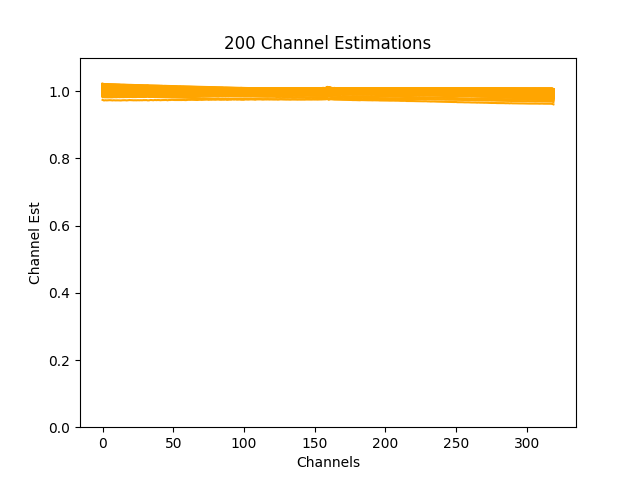

In [2]:
channel_ests = []

fig, axs = plt.subplots()

for i in range(1,301,1):
    input = np.load("../masters_large_data/received_data/multi_receive/channel_estimations/channel_est"+str(i)+".npy")
    print(input)
    channel_ests.append(input)
    axs.plot(input,color='orange')

axs.set_ybound(0.0,1.1)
axs.set_title("200 Channel Estimations")
axs.set_xlabel("Channels")
axs.set_ylabel("Channel Est")
plt.show()



[0.63205766 0.34436646 0.01649273]


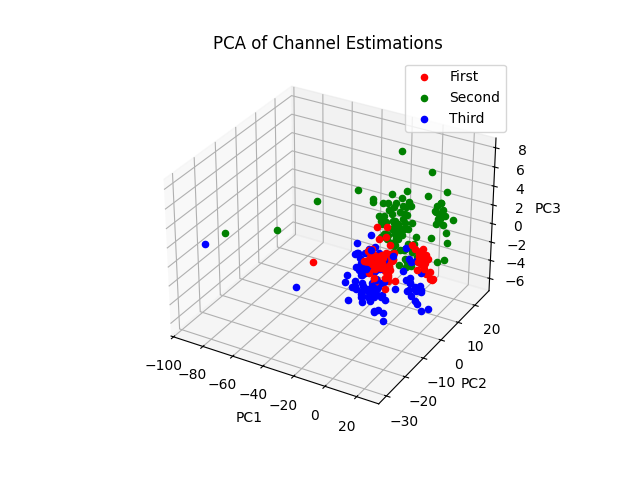

In [3]:
# Parameters
num_captures = 300
window_size =  320 # We'll use the first 8192 samples of each
labels = (
    ['First'] * 100 + 
    ['Second'] * 100 +
    ['Third'] * 100
)

X = []

# # Extract FFT magnitude features from each variable
# for i in range(1, num_captures + 1):
#     capture = globals()[f"capture{i}"][:window_size]  # Access variable by name
#     # Downsample to 12.5k samples
#     downsample_factor = 12500
#     capture_ds = decimate(capture, downsample_factor)
#     X.append(capture_ds)


X = np.array(channel_ests)


# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

color_map = {'First': 'r', 'Second': 'g', 'Third': 'b'}

for i in range(len(X_pca)):
    ax.scatter(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2],
               color=color_map[labels[i]],
               label=labels[i] if i % 100 == 0 else "")  # Avoid repeated labels

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("PCA of Channel Estimations")
# ax.view_init(elev=, azim=0)  # ← change perspective to top-down
ax.legend()
plt.show()

